# Workshop: Robust Digital Watermarking (DWT-DCT vs. RivaGAN)

This notebook walks through **embedding**, **extracting**, and **robustness testing** of digital watermarks using:
- **DWT-DCT** — classical, signal-processing based (no training needed)
- **RivaGAN** — learning-based, uses a pre-trained encoder/decoder network

We will also run common attacks (JPEG compression, noise, cropping), measure image quality (PSNR / SSIM), and visualize with images, difference maps, tables, and charts.

## 0. Setup
Run the following cell to install and import all dependencies.
Works on **Google Colab**, **Jupyter Lab**, or local Jupyter.

In [ ]:
# Install packages (uncomment if needed)
!pip -q install invisible-watermark opencv-python-headless matplotlib numpy pandas scikit-image onnxruntime

import os, io, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imwatermark import WatermarkEncoder, WatermarkDecoder

# We use PSNR/SSIM to measure watermark invisibility
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity  as compute_ssim

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 100})
print("✅ All imports loaded successfully.")

✅ All imports loaded successfully.


## 1. Load an Input Image

Set `IMAGE_PATH` below. If the file doesn't exist, we **auto-download** a sample image so the notebook never fails on first run.

The image is center-cropped to **16:9** and resized to **1920×1080** for consistency.

Image shape: (1080, 1920, 3)


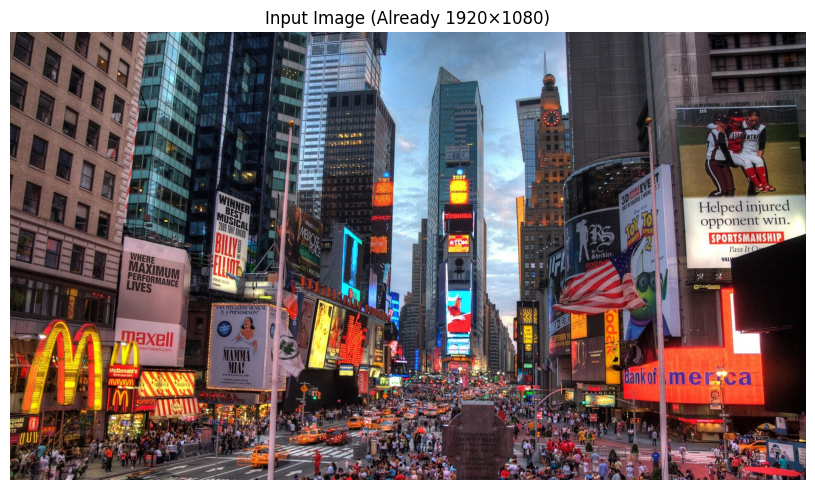

In [ ]:
IMAGE_PATH = "/content/nyc.jpg"

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(
        f"找不到图片: {IMAGE_PATH}\n"
        "请先把图片上传到当前 notebook 所在目录。"
    )

img_bgr = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Cannot read: {IMAGE_PATH}")

# ✅ 不再 crop / resize
print(f"Image shape: {img_bgr.shape}")
img_1080p = img_bgr

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Input Image (Already 1920×1080)")
plt.axis("off")
plt.tight_layout()
plt.show()


## 2. Helper Functions

We define reusable utilities:
- **`show_comparison()`** — side-by-side: Original vs Watermarked vs Amplified Difference
- **`quality_table()`** — compute PSNR & SSIM for watermarked images
- **`bit_accuracy()`** — measure how many bits survive an attack (0.0 – 1.0)

In [ ]:
def show_comparison(original, watermarked, method_name, amp_factor=10):
    """Show Original | Watermarked | Amplified Difference (×amp_factor)."""
    diff = cv2.absdiff(original, watermarked)
    diff_amp = np.clip(diff.astype(np.float32) * amp_factor, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, img, title in zip(axes, [original, watermarked, diff_amp],
            ["Original", f"{method_name} Watermarked", f"Difference (×{amp_factor})"]):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=13)
        ax.axis("off")
    plt.suptitle(f"Watermark Embedding — {method_name}", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

def quality_metrics(original, watermarked):
    """Return (PSNR, SSIM) between two BGR images."""
    orig_rgb = cv2.cvtColor(original,    cv2.COLOR_BGR2RGB)
    wm_rgb   = cv2.cvtColor(watermarked, cv2.COLOR_BGR2RGB)
    psnr = compute_psnr(orig_rgb, wm_rgb)
    ssim = compute_ssim(orig_rgb, wm_rgb, channel_axis=2)
    return round(psnr, 2), round(ssim, 4)

def bit_accuracy(original_bytes, decoded_bytes):
    """Compute fraction of matching bits between two byte strings."""
    if decoded_bytes is None or len(decoded_bytes) == 0:
        return 0.0
    orig = np.unpackbits(np.frombuffer(original_bytes, dtype=np.uint8))
    dec  = np.unpackbits(np.frombuffer(decoded_bytes,  dtype=np.uint8))
    n = min(len(orig), len(dec))
    return float(np.mean(orig[:n] == dec[:n]))

def try_decode(decoder, attacked_bgr, method):
    """Safely decode watermark; return bytes or None."""
    try:
        out = decoder.decode(attacked_bgr, method)
        if out is None or out == b"":
            return None
        return out
    except Exception:
        return None

print("✅ Helper functions defined.")

✅ Helper functions defined.


## 3. Watermark Method A — DWT-DCT (Classical)

DWT-DCT embeds the watermark in the **frequency domain** using Discrete Wavelet Transform + Discrete Cosine Transform. No neural network is needed.

We embed `SECURE2025` (10 ASCII chars = 80 bits) and immediately verify decoding.

Embedded         : SECURE2025
Raw decoded bytes: b'SECURE2025'
Decoded text     : SECURE2025


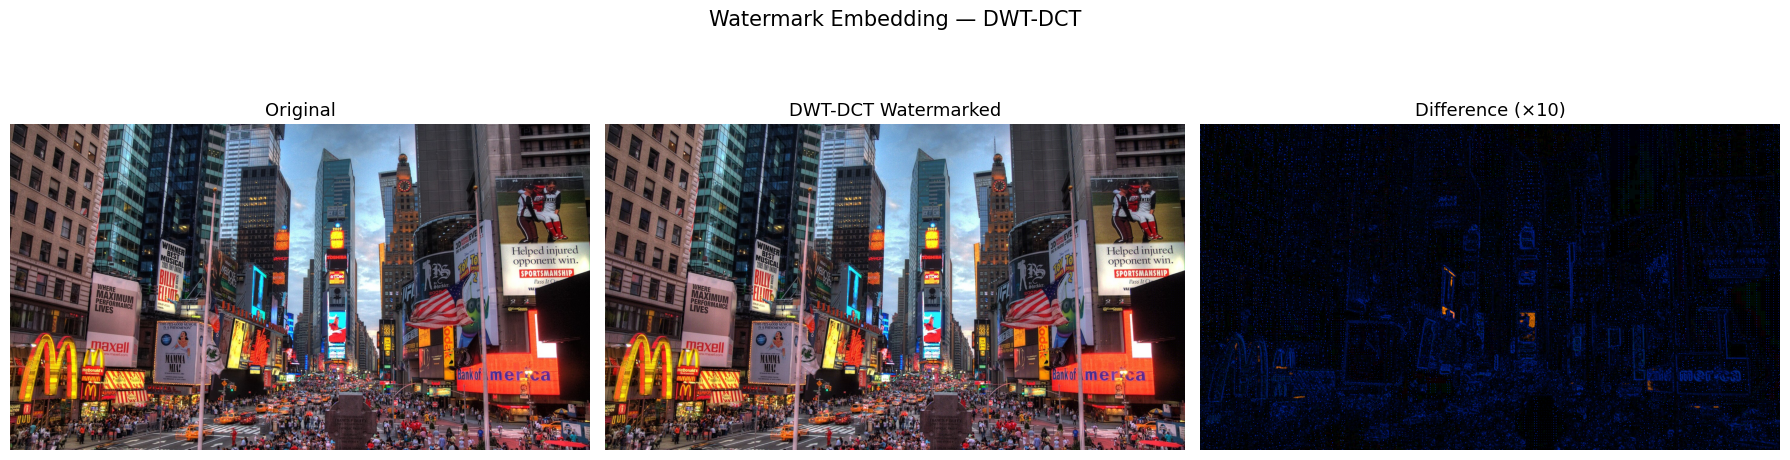

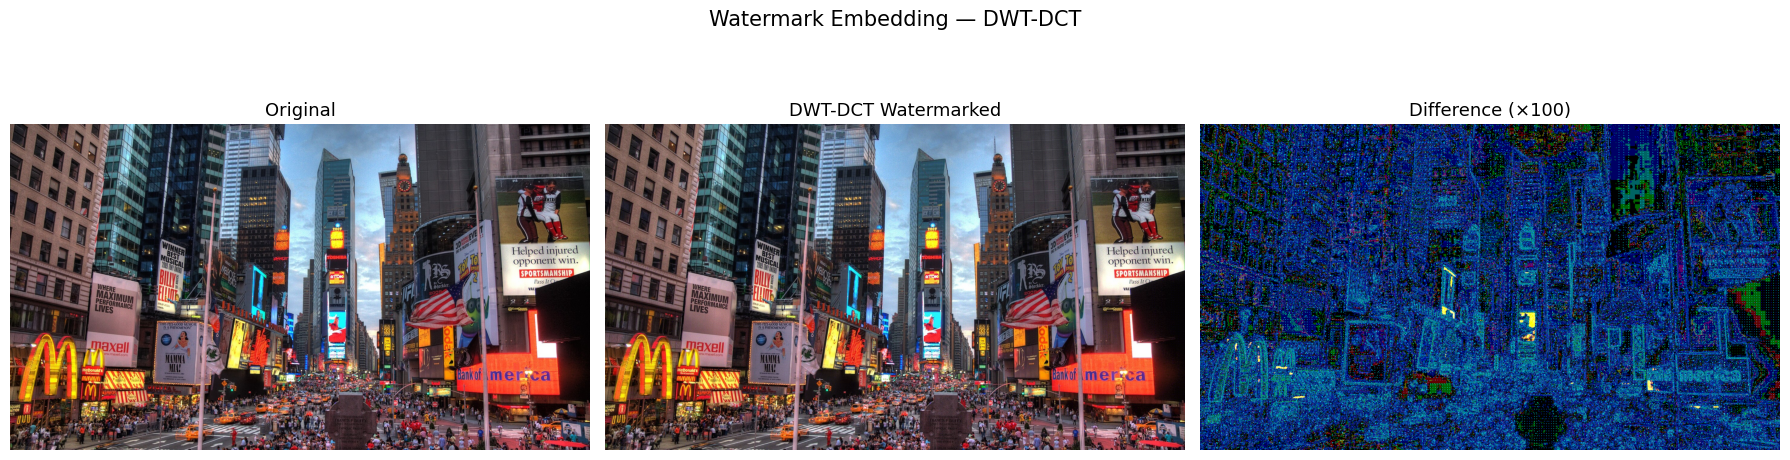

80

In [ ]:
# wm_text_dwt = "SECURE2025"  # 10 ASCII chars = 80 bits

# # --- Encode ---
# enc_dwt = WatermarkEncoder()
# enc_dwt.set_watermark("bytes", wm_text_dwt.encode("utf-8"))
# wm_dwt_bgr = enc_dwt.encode(img_1080p, "dwtDct").astype(np.uint8)

# # --- Decode & verify ---
# dec_dwt = WatermarkDecoder("bytes", len(wm_text_dwt.encode("utf-8")))
# decoded_dwt = dec_dwt.decode(wm_dwt_bgr, "dwtDct")
# print(f"Embedded : {wm_text_dwt}")
# print(f"Decoded  : {decoded_dwt.decode('utf-8', errors='ignore')}")

# # --- Quality metrics ---
# psnr_dwt, ssim_dwt = quality_metrics(img_1080p, wm_dwt_bgr)
# print(f"PSNR     : {psnr_dwt} dB")
# print(f"SSIM     : {ssim_dwt}")

# # --- Visual comparison with difference map ---

wm_text_dwt = "SECURE2025"

enc_dwt = WatermarkEncoder()
enc_dwt.set_watermark("bytes", wm_text_dwt.encode("utf-8"))
wm_dwt_bgr = enc_dwt.encode(img_1080p, "dwtDct").astype(np.uint8)

# 这里要乘 8
dec_dwt = WatermarkDecoder("bytes", len(wm_text_dwt.encode("utf-8")) * 8)
decoded_dwt = dec_dwt.decode(wm_dwt_bgr, "dwtDct")

print("Embedded         :", wm_text_dwt)
print("Raw decoded bytes:", decoded_dwt)
print("Decoded text     :", decoded_dwt.decode("utf-8", errors="replace"))

show_comparison(img_1080p, wm_dwt_bgr, "DWT-DCT")
show_comparison(img_1080p, wm_dwt_bgr, "DWT-DCT", amp_factor=100)
s

## 4. Watermark Method B — RivaGAN (Deep Learning)

RivaGAN uses a **pre-trained encoder-decoder network**. The provided model supports a **32-bit** payload (= 4 ASCII characters).

We embed `test` and verify, then compare the difference map with DWT-DCT.

Embedded : test
Decoded  : test
PSNR     : 40.48 dB
SSIM     : 0.9834


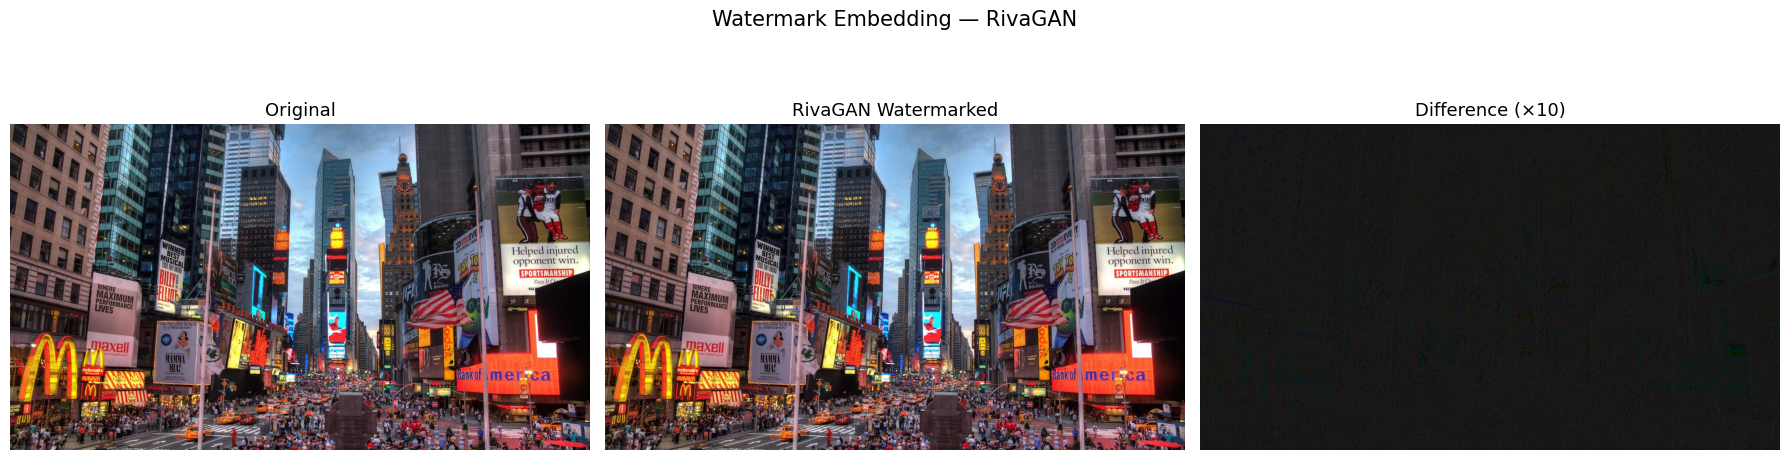

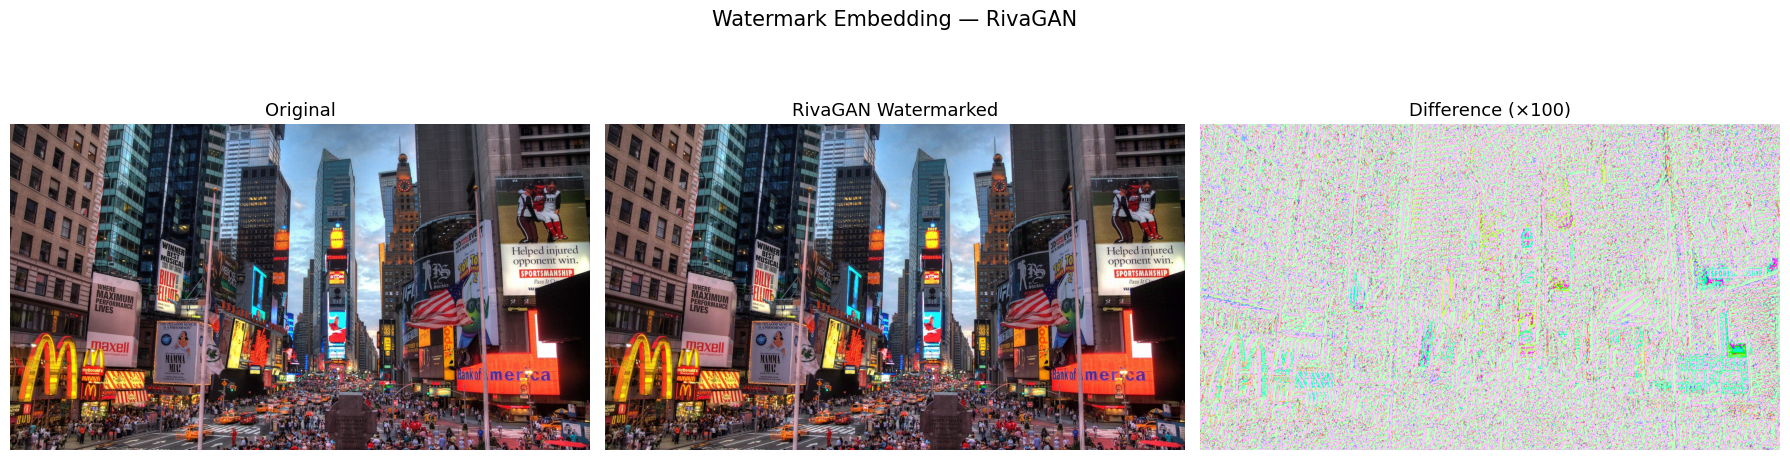

In [ ]:
# Load pre-trained RivaGAN model
WatermarkEncoder.loadModel()
WatermarkDecoder.loadModel()

wm_text_riva = "test"  # 4 chars = 32 bits (model limit)

# --- Encode ---
enc_riva = WatermarkEncoder()
enc_riva.set_watermark("bytes", wm_text_riva.encode("utf-8"))
wm_riva_bgr = enc_riva.encode(img_1080p, "rivaGan").astype(np.uint8)

# --- Decode & verify ---
dec_riva = WatermarkDecoder("bytes", 32)
decoded_riva = dec_riva.decode(wm_riva_bgr, "rivaGan")
print(f"Embedded : {wm_text_riva}")
print(f"Decoded  : {decoded_riva.decode('utf-8', errors='ignore')}")

# --- Quality metrics ---
psnr_riva, ssim_riva = quality_metrics(img_1080p, wm_riva_bgr)
print(f"PSNR     : {psnr_riva} dB")
print(f"SSIM     : {ssim_riva}")

# --- Visual comparison with difference map ---
show_comparison(img_1080p, wm_riva_bgr, "RivaGAN")
show_comparison(img_1080p, wm_riva_bgr, "RivaGAN", amp_factor=100)

### Quality Comparison Table

Higher PSNR and SSIM indicate better visual fidelity. In general, PSNR above 35 dB and SSIM close to 1 suggest that watermark distortions are difficult to perceive.

In [ ]:
quality_df = pd.DataFrame([
    {"Method": "DWT-DCT",  "Payload": wm_text_dwt,  "Bits": len(wm_text_dwt)*8, "PSNR (dB)": psnr_dwt, "SSIM": ssim_dwt},
    {"Method": "RivaGAN",  "Payload": wm_text_riva, "Bits": len(wm_text_riva)*8, "PSNR (dB)": psnr_riva, "SSIM": ssim_riva},
])
quality_df.style.format({"PSNR (dB)": "{:.2f}", "SSIM": "{:.4f}"}).set_caption("Watermark Invisibility")

,Method,Payload,Bits,PSNR (dB),SSIM
0,DWT-DCT,SECURE2025,80,38.84,0.9820
1,RivaGAN,test,32,40.48,0.9834
